In [2]:
import torch
import numpy as np
from src.util.celano_lab_scripts import process_image

IMG_SIZE_UM=2.0
fp = "/playpen/mufan/levi/tianlong-chen-lab/material-super-resolution/data/raw-data/1-23-25/img3cbMoS2-Sef-New-Area1-position 4 (2um-good) (hivac)_250102_Current_Backward_013.npy"
data = torch.Tensor(np.load(fp)).unsqueeze(0)
data_subset = data[:, :128, :128]
process_image(data, 2.0)

{'coverage_percentage': 98.72093200683594,
 'total_len_detected_curves': 27.42259545205161,
 'total_area_circular_shapes': 1.0794525146484375,
 'total_area_extended_shapes': 0.0282440185546875,
 'total_defect_area': 0.0004225526936352253,
 'num_circular_shapes': 1409,
 'num_extended_shapes': 5,
 'num_curved_lines': 5,
 'average_surface_current': 13.335134774195012}

In [20]:
import torch
import pprint

from tqdm import tqdm
from src.datasets.mos2_sef import MOS2SEFDataset, Formulation
from src.models.our_method.swin_cafm import SwinCAFM
from src.models.our_method.older_surrogate import MultiHeadOlderSurrogate

surrogate_weights = "/playpen/mufan/levi/tianlong-chen-lab/material-super-resolution/__exps__/y-task-formulations/p(y | y_sparse)/e. surrogate standalone train-runs/2025-02-08_12-36-35_older_surrogate_mh-ViT-l[-2]+layernorm/older_surrogate_mh-ViT-l[-2]+layernorm_latest_older_surrogate.pth"
surrogate = torch.load(surrogate_weights).cuda().float()

model = SwinCAFM.get().cuda().float()
model.train()
surrogate.eval()

formulation = Formulation.P_Y_BAR_Y_SPARSE
train_dataset = MOS2SEFDataset("train", formulation, 128, 1, 750)
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=1, shuffle=False, num_workers=0)
val_dataset = MOS2SEFDataset("val", formulation, 128, 1, 250)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)

optimizer = torch.optim.Adam(model.parameters())

IMG_SIZE_UM=2.0
values = {}

diffs_arr = []

def sample():
    
    for dataloader in [train_dataloader, val_dataloader]:
        for i, data in tqdm(enumerate(dataloader), total=len(dataloader)):
            optimizer.zero_grad()
            
            y = data['y'].cuda().float()
            mask = data['mask'].cuda().float()
            y_sparse = (mask * y).cuda().float()
            y_hat = model(y_sparse).cuda().float()
            
            char_gt = surrogate(y)
            char_pred = surrogate(y_hat)
            
            diffs = char_pred - char_gt
            diffs_arr.append(diffs.squeeze(0).detach().cpu().numpy())
                
            loss = torch.nn.functional.l1_loss(y, y_hat)
            loss.backward(); optimizer.step()
                      
sample()

/tmp/ipykernel_2340417/2370267346.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  surrogate = torch.load(surrogate_weights).cuda().float()
100%|██████████| 250/250 [00:

In [ ]:
np.array(diffs_arr).shape

(1000, 9)

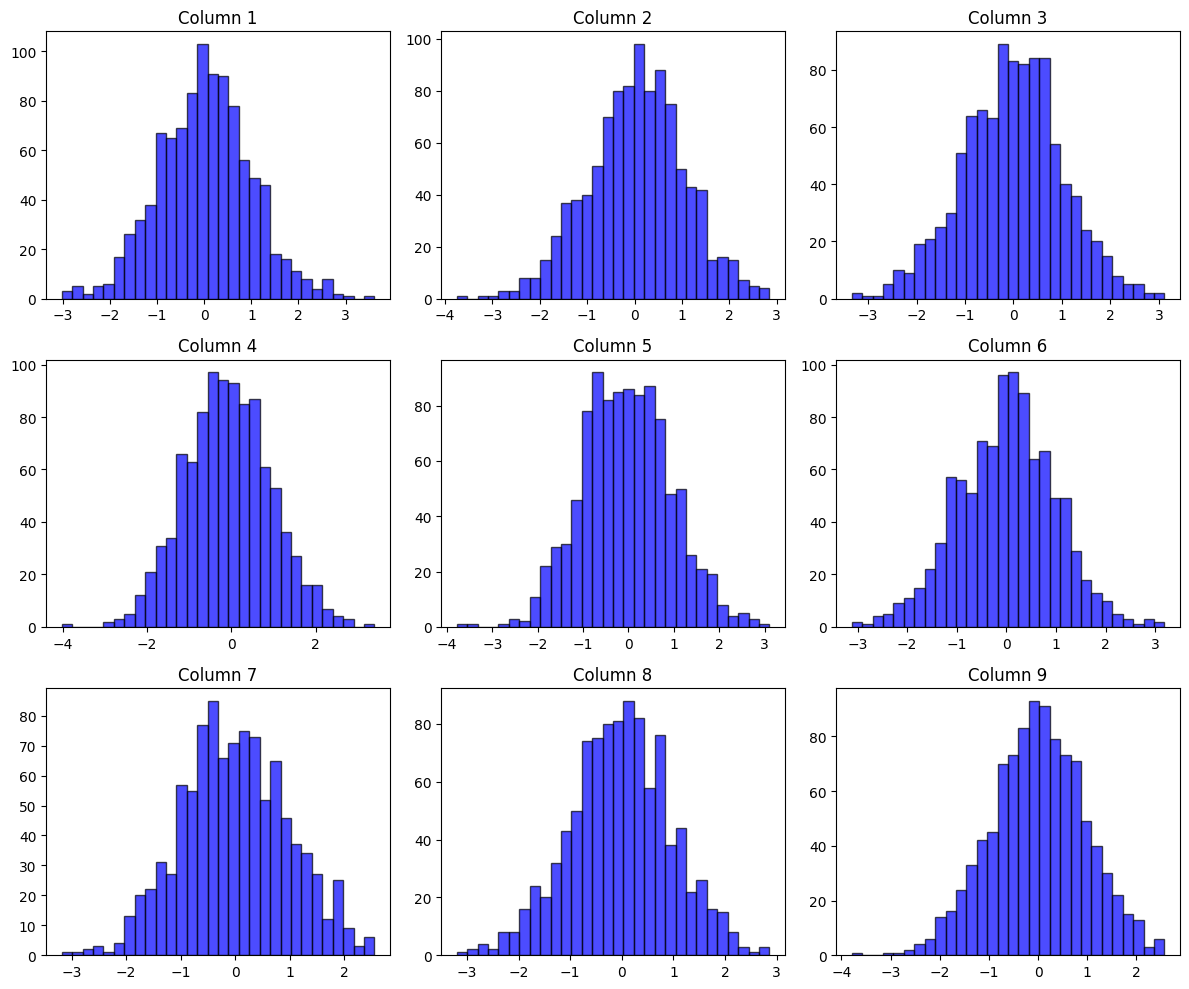

In [18]:
import matplotlib.pyplot as plt

data = np.array(diffs_arr)

# Generate random data (Example)
data = np.random.randn(1000, 9)  # Replace with your actual data

# Create a 3x3 grid of subplots
fig, axes = plt.subplots(3, 3, figsize=(12, 10))  

# Plot histograms for each column
for i in range(9):
    row, col = divmod(i, 3)  # Determine subplot position
    axes[row, col].hist(data[:, i], bins=30, alpha=0.7, color='b', edgecolor='black')
    axes[row, col].set_title(f'Column {i+1}')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


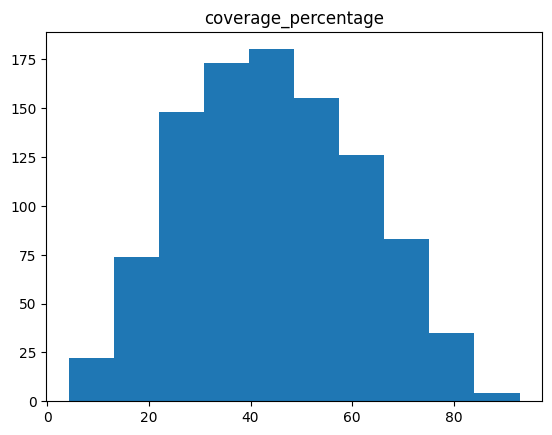

mean: 44.4280212402, std: 17.3024880015


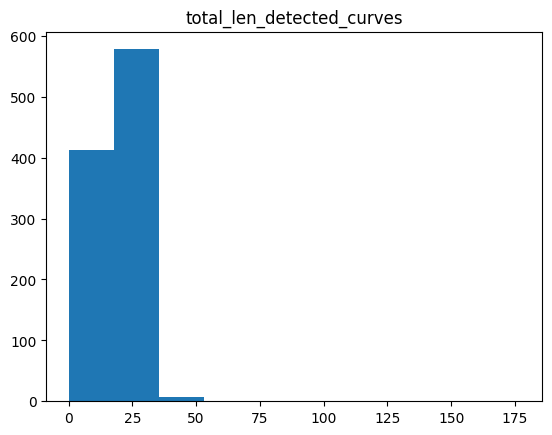

mean: 19.5867083795, std: 8.5186785199


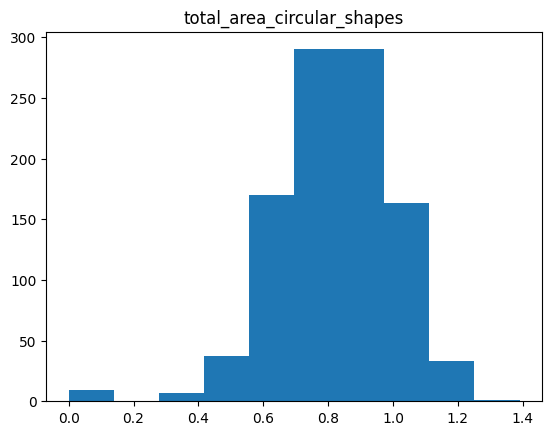

mean: 0.8205949707, std: 0.1801719471


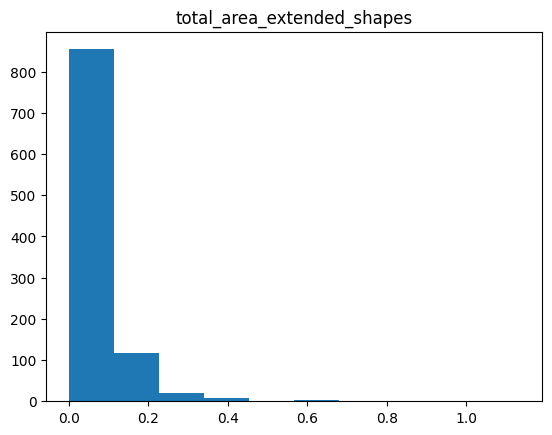

mean: 0.0423656006, std: 0.0824119428


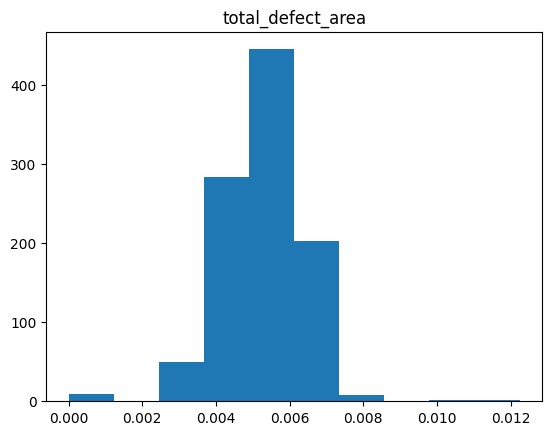

mean: 0.0052670933, std: 0.0011257379


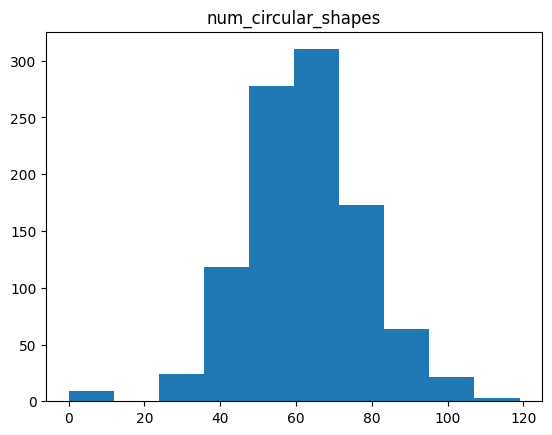

mean: 62.4170000000, std: 15.8902206089


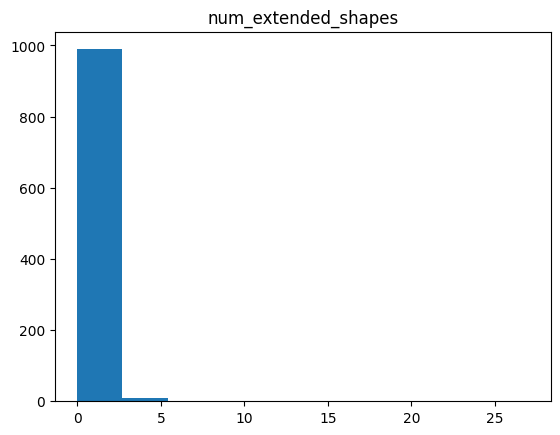

mean: 0.4580000000, std: 1.2450847361


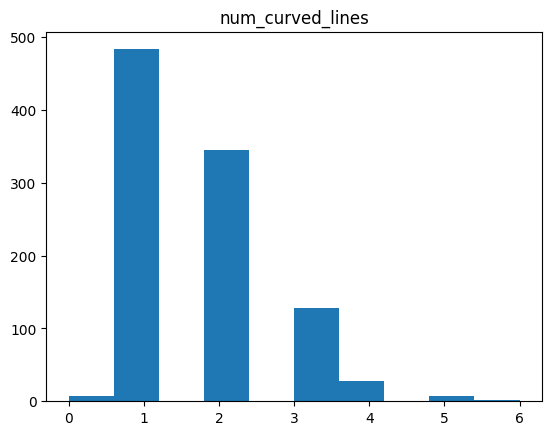

mean: 1.7160000000, std: 0.8748394138


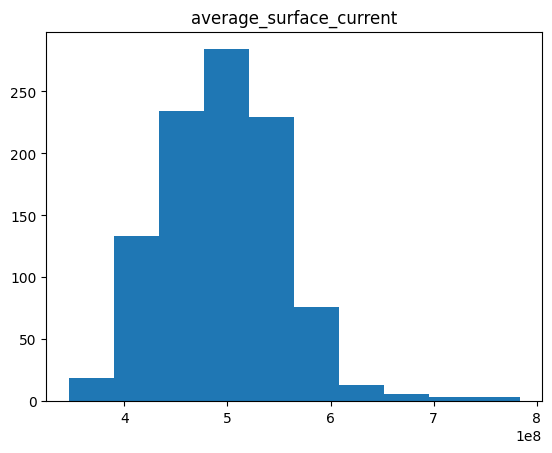

mean: 494717020.4520224929, std: 58214103.4623958841


In [7]:
import matplotlib.pyplot as plt

# plot a histogram of all values; include mean and std stats
for k, v in values.items():
    plt.hist(v)
    plt.title(k)
    plt.show()
    print(f"mean: {np.mean(v):.10f}, std: {np.std(v):.10f}")

In [2]:
import pprint
import torch
import numpy as np
from src.util.celano_lab_scripts import process_image
from tqdm import tqdm
from src.datasets.mos2_sef_surrogate import MOS2SefOLDERSurrogate, Formulation

formulation = Formulation.P_Y_BAR_Y_SPARSE
train_dataset = MOS2SefOLDERSurrogate("train", formulation, 128, 1, 7500)
train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=1, shuffle=False, num_workers=0
)
val_dataset = MOS2SefOLDERSurrogate("val", formulation, 128, 1, 2500)
val_dataloader = torch.utils.data.DataLoader(
    val_dataset, batch_size=1, shuffle=False, num_workers=0
)

IMG_SIZE_UM=2.0
values = {}
for dataloader in [train_dataloader, val_dataloader]:
    for i, data in tqdm(enumerate(dataloader)):
        data = data['y']
        data_subset = data[:, :128, :128]
        char_data = process_image(data, IMG_SIZE_UM)
        for k, v in char_data.items():
            if k not in values:
                values[k] = []
            values[k].append(v)

7500it [03:36, 34.58it/s]
2500it [01:11, 34.81it/s]


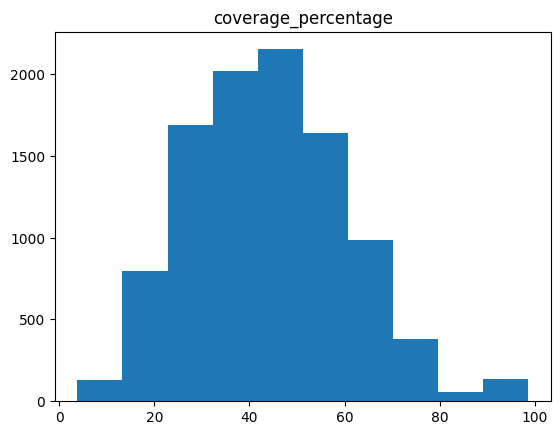

mean: 44.0220239258, std: 16.5272924169


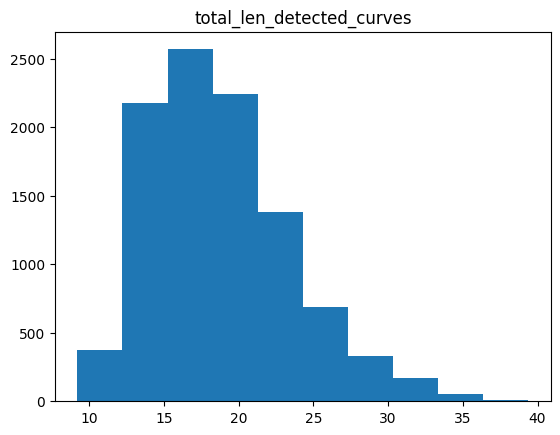

mean: 18.7612568837, std: 4.7076850134


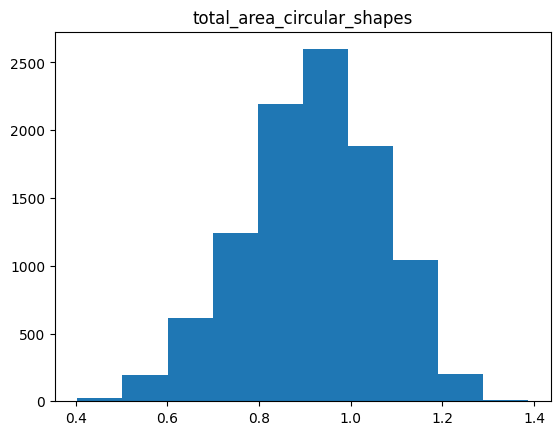

mean: 0.9166571045, std: 0.1489250416


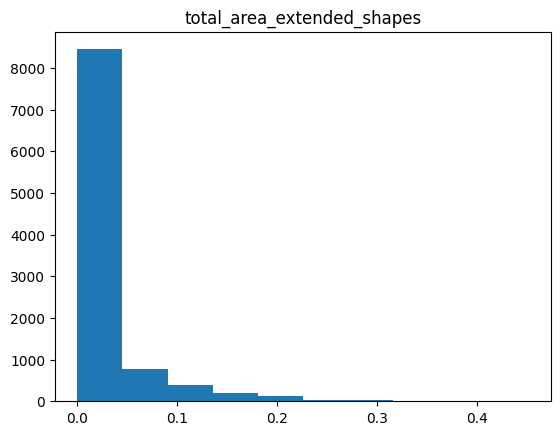

mean: 0.0176557373, std: 0.0472025983


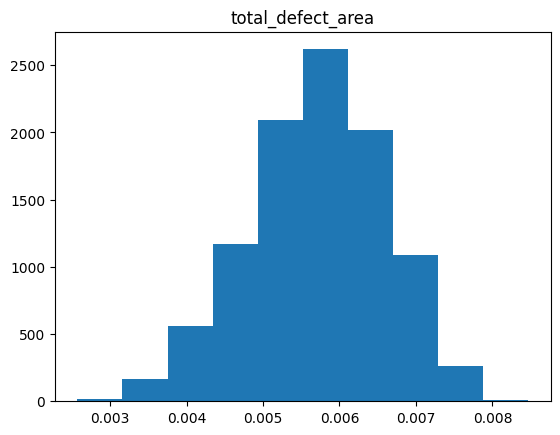

mean: 0.0057025930, std: 0.0008857003


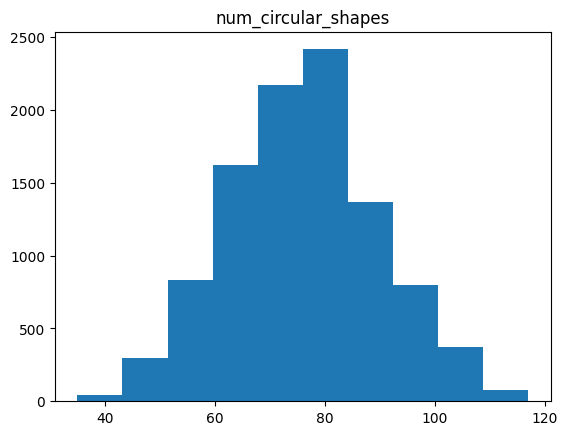

mean: 75.8980000000, std: 13.7804933148


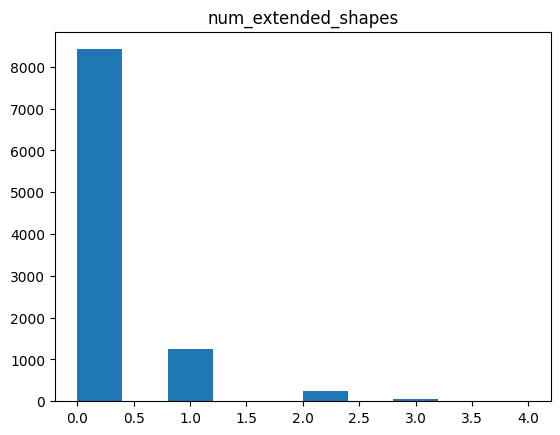

mean: 0.1977000000, std: 0.5038002680


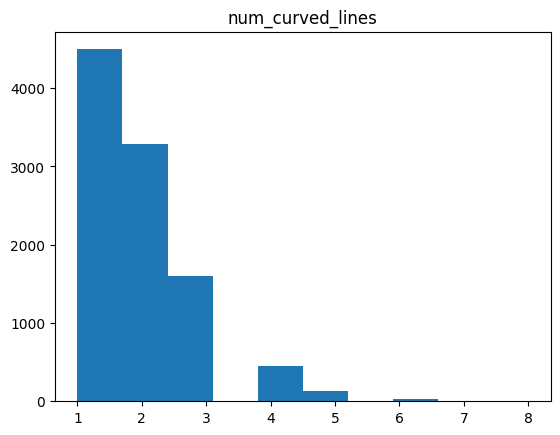

mean: 1.8537000000, std: 0.9735996662


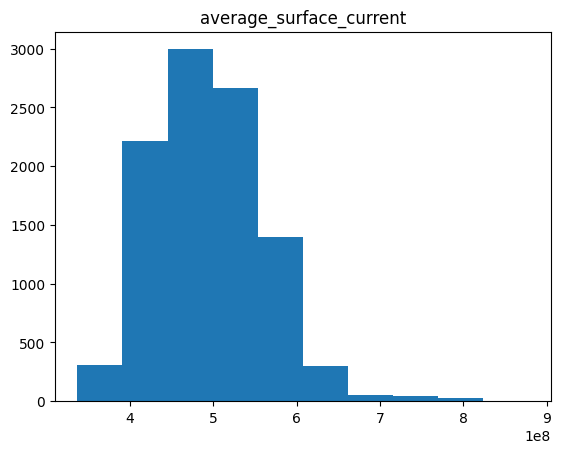

mean: 494253719.4639444351, std: 65495428.9935829639


In [3]:
import matplotlib.pyplot as plt

# plot a histogram of all values; include mean and std stats
for k, v in values.items():
    plt.hist(v)
    plt.title(k)
    plt.show()
    print(f"mean: {np.mean(v):.10f}, std: {np.std(v):.10f}")